# Treated MonoCulture Math Modelling — 20k IC50 (Julia)

Uses DifferentialEquations.jl + Optimization.jl with an ODEProblem and a Hill-type drug effect, mirroring the style of the untreated notebook.

## 1) Packages
Load or install required Julia packages for treated IC50 modelling (logistic growth with Hill drug effect).

In [1]:
# 1) Packages (minimal)
using Pkg
pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations", "Optim", "Plots"
]
for p in pkgs
    try
        Base.eval(Main, :(import $(Symbol(p))))
    catch
        Pkg.add(p)
        Base.eval(Main, :(import $(Symbol(p))))
    end
end
println("✓ Packages ready: " * join(pkgs, ", "))

✓ Packages ready: CSV, DataFrames, Statistics, DifferentialEquations, Optim, Plots



## 2) Imports & Paths
Bring into scope the packages, set plotting defaults, and define filesystem paths.

In [2]:
# 2) Imports & Paths
using CSV, DataFrames, Statistics
using DifferentialEquations, Optimization, OptimizationOptimJL, BlackBoxOptim
using Optim
using Plots
default(fmt=:png, legend=:topright, lw=2, size=(900,550))

# Root and directories
ROOT = raw"c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics"
UNT_PARAMS = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")
TREATED_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "IC50")
mkpath(OUT_DIR)
println("Using treated averages dir: " * TREATED_DIR)
println("Output directory: " * OUT_DIR)

Using treated averages dir: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
Output directory: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50


## 3) Utilities (Loaders)
Helpers to load treated day averages and untreated baseline r,K parameters.

In [3]:
# 3) Utilities (Loaders)
function load_day_averages(path::AbstractString)
    @assert isfile(path) "Missing CSV: $path"
    df = CSV.read(path, DataFrame)
    daycol = :Day ∈ names(df) ? :Day : Symbol(first(filter(n -> occursin("day", lowercase(String(n))), names(df))))
    valcol = Symbol("Mean Cells") ∈ names(df) ? Symbol("Mean Cells") : Symbol(first(filter(n -> occursin("mean", lowercase(String(n))) && occursin("cells", lowercase(String(n))), names(df))))
    x = Float64.(df[!, daycol]); y = Float64.(df[!, valcol])
    perm = sortperm(x); x = x[perm]; y = y[perm]
    return x, y
end

function load_rk_table(csv_path::AbstractString)
    df = CSV.read(csv_path, DataFrame)
    # Filter for 20k density only and create lookup by CellLine
    df_20k = filter(row -> row.Density == "20k", df)
    return Dict(Symbol(row.CellLine) => (Float64(row.r), Float64(row.K)) for row in eachrow(df_20k))
end

println("Loaded utility functions")

Loaded utility functions


## 4) Model (Logistic with Hill Inhibition)
Defines Hill function, ODE, and solver for IC50=1µM treatment. Only the Hill coefficient (n) is estimated.

In [ ]:
# 4) Model (Logistic with Hill Inhibition, IC50 = 1µM)
# Hill inhibition: effect(d) = d^n / (IC50^n + d^n)
# For IC50 treatment, dose = IC50 = 1µM, so we only estimate the Hill coefficient n
hill(dose, IC50, n) = dose^n / (IC50^n + dose^n)

function treated_logistic!(du, u, p, t)
    r, K, IC50, n, dose = p
    eff = r * (1 - hill(dose, IC50, n))
    du[1] = eff * u[1] * (1 - u[1] / K)
end

function solve_model(x::Vector{Float64}, y::Vector{Float64}, r, K; IC50=1.0, n=1.0, dose=1.0, density="20k")
    # Set day 0 cell count based on seeding density (20k for this notebook)
    day0_cells = if density == "30k"
        100.0
    elseif density == "20k"
        67.0
    else
        max(y[1], eps())  # fallback to original behavior
    end
    
    u0 = [day0_cells]; tspan = (x[1], x[end])
    p = [r, K, IC50, n, dose]
    prob = ODEProblem(treated_logistic!, u0, tspan, p)
    sol = solve(prob, Rosenbrock23(); saveat=x, reltol=1e-6, abstol=1e-6)
    return sol
end

println("Model ready (IC50 = 1µM fixed, estimating Hill coefficient n only)")

Model ready (IC50 = 1µM fixed, estimating Hill coefficient n only)


## 5) Fitting Helper
Estimates only the Hill coefficient (n) with dose fixed at 1µM (actual experimental concentration).

In [ ]:
# 5) Hill Coefficient Fitting (dose = 1µM fixed, IC50 = 1µM)

function _safe_loss_hill_only(n, x, y, r, K, dose_fixed, IC50_fixed; density="20k")
    if !isfinite(n) || n <= 0 || n > 10.0
        return 1e14
    end
    try
        # Normalize data to reduce bias toward larger values
        y_max = maximum(y)
        y_normalized = y ./ y_max
        K_normalized = K / y_max
        
        sol = solve_model(x, y_normalized, r, K_normalized; IC50=IC50_fixed, n=n, dose=dose_fixed, density=density)
        pred = getindex.(sol.u, 1)
        any(!isfinite, pred) && return 1e13
        return sum(abs2, y_normalized .- pred)
    catch
        return 1e12
    end
end

function _run_single_nm_scalar(loss, lower, upper, n0; maxiters=4000)
    opt = Optim.Options(iterations=maxiters, show_trace=false, store_trace=false, show_every=0)
    Optim.optimize(loss, lower, upper, n0, Optim.Fminbox(Optim.Brent()), opt)
end

function fit_hill_coefficient_1uM(x::Vector{Float64}, y::Vector{Float64}, rK::Tuple{Float64,Float64}; dose_fixed=1.0, IC50_fixed=1.0, density="20k")
    r, K = rK
    lower = 0.1; upper = 10.0  # Allow wider range for Hill coefficient
    loss(n) = _safe_loss_hill_only(n, x, y, r, K, dose_fixed, IC50_fixed; density=density)
    
    # Try multiple starting points for Hill coefficient
    best_res = nothing
    best_loss = Inf
    
    # Test various Hill coefficients - some may work better for specific data patterns
    starting_points = [0.2, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
    
    for n_start in starting_points
        try
            res = _run_single_nm_scalar(loss, lower, upper, n_start; maxiters=3000)
            if Optim.minimum(res) < best_loss
                best_res = res
                best_loss = Optim.minimum(res)
            end
        catch
            continue
        end
    end
    
    if best_res === nothing
        @warn "All optimization attempts failed"
        return nothing
    end
    
    n̂ = Optim.minimizer(best_res)
    sol̂ = try solve_model(x, y, r, K; IC50=IC50_fixed, n=n̂, dose=dose_fixed, density=density) catch; nothing end
    
    return (; x=copy(x), y=copy(y), r, K, IC50=IC50_fixed, dose=dose_fixed, n=n̂, ssr=best_loss, sol=sol̂)
end

println("Hill coefficient fitting function ready (dose = 1µM fixed, IC50 = 1µM)")

Hill coefficient fitting function ready (dose = 1µM fixed, IC50 = 1µM)


## 7) Run Fits & Plot
Load untreated baseline r,K, perform treated fits for naive and cis lines, and plot results.

## 6) Quick Data Inspection & Plot
Load raw treated naive/cis CSVs, display first rows, and plot the time-course before fitting.

Inspecting treated day-average files:
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780Naive_day_averages.csv
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780cis_day_averages.csv
Naive rows: 14  Cis rows: 14
Naive rows: 14  Cis rows: 14


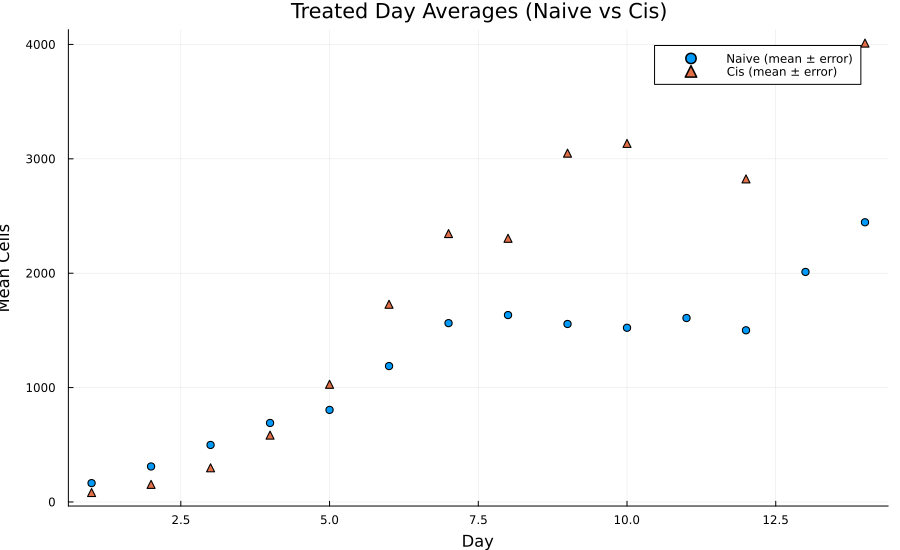

Day-average inspection complete.


In [6]:
# 6) Quick Data Inspection & Plot (Day Averages)
# Use pre-computed day-average CSVs for treated Naive and Cis lines.
AVG_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")
naive_avg = joinpath(AVG_DIR, "A2780Naive_day_averages.csv")
cis_avg   = joinpath(AVG_DIR, "A2780cis_day_averages.csv")
println("Inspecting treated day-average files:\n  " * naive_avg * "\n  " * cis_avg)
@assert isfile(naive_avg) "Missing naive day averages: $(naive_avg)"
@assert isfile(cis_avg)   "Missing cis day averages: $(cis_avg)"

function load_day_avg_with_err(path::AbstractString)
    df = CSV.read(path, DataFrame)
    daycol = :Day ∈ names(df) ? :Day : first(filter(c -> occursin("day", lowercase(String(c))), names(df)))
    valcol = Symbol("Mean Cells") ∈ names(df) ? Symbol("Mean Cells") : first(filter(c -> occursin("mean", lowercase(String(c))) && occursin("cells", lowercase(String(c))), names(df)))
    errcol = Symbol("SEM Cells") ∈ names(df) ? Symbol("SEM Cells") : (Symbol("SD Cells") ∈ names(df) ? Symbol("SD Cells") : nothing)
    x = Float64.(df[!, daycol]); y = Float64.(df[!, valcol]); yerr = errcol === nothing ? nothing : Float64.(df[!, errcol])
    perm = sortperm(x); x = x[perm]; y = y[perm]; yerr = isnothing(yerr) ? nothing : yerr[perm]
    return x, y, yerr, df
end

xN, yN, yerrN, dfN = load_day_avg_with_err(naive_avg)
xC, yC, yerrC, dfC = load_day_avg_with_err(cis_avg)
println("Naive rows: ", nrow(dfN), "  Cis rows: ", nrow(dfC))

plt = scatter(xN, yN; yerror=yerrN, marker=:circle, label="Naive (mean ± error)", xlabel="Day", ylabel="Mean Cells", title="Treated Day Averages (Naive vs Cis)")
scatter!(plt, xC, yC; yerror=yerrC, marker=:utriangle, label="Cis (mean ± error)")
display(plt)
println("Day-average inspection complete.")

Loaded baseline parameters:
  A2780cis: r = 0.7155, K = 3914.9
  A2780Naive: r = 0.7704, K = 4068.6

=== Estimating IC50 values from 1µM treatment response ===
  No inhibition observed - drug ineffective at 1µM
✗ A2780cis: No inhibition observed at 1µM - IC50 >> 1µM



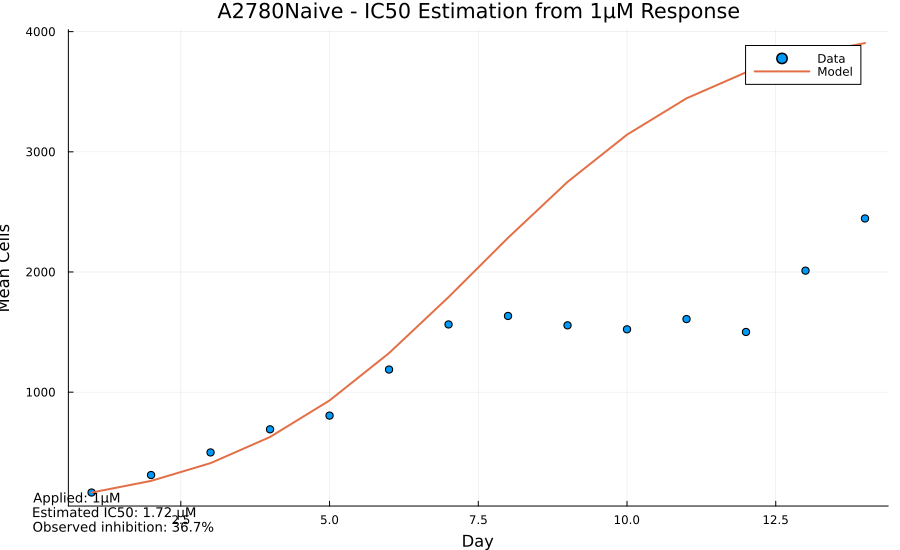

✓ A2780Naive:
    Applied dose: 1.0 µM
    Estimated IC50: 1.722 µM
    Observed inhibition: 36.7%
    Model fit SSR: 1.798e7

✓ Results exported to: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50\ic50_estimates_from_1uM_treatment.csv



Row,cell_line,r,K,dose_applied,estimated_IC50,observed_inhibition_percent,SSR
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,A2780cis,0.71548,3914.9,1.0,Inf,0.0,Inf
2,A2780Naive,0.770405,4068.59,1.0,1.72241,36.7321,1.79759e7


In [ ]:
# 7) Estimate IC50 values from 1µM treatment data
for sym in (:xN, :yN, :xC, :yC)
    @assert isdefined(Main, sym) "Run Section 6 first (data load)."
end

# Load untreated baseline parameters
rk = load_rk_table(UNT_PARAMS)
println("Loaded baseline parameters:")
for (cell_line, (r, K)) in rk
    println("  $cell_line: r = $(round(r, digits=4)), K = $(round(K, digits=1))")
end

# Estimate IC50 values from 1µM treatment response
println("\n=== Estimating IC50 values from 1µM treatment response ===")
fits = Dict{Symbol,Any}(
    :A2780Naive => fit_ic50_with_fixed_dose(copy(xN), copy(yN), rk[:A2780Naive]; dose_fixed=1.0, n_fixed=1.0, density="20k"),
    :A2780cis   => fit_ic50_with_fixed_dose(copy(xC), copy(yC), rk[:A2780cis]; dose_fixed=1.0, n_fixed=1.0, density="20k")
)

# Plot results and export
for (k,f) in fits
    if f !== nothing && f.sol !== nothing
        plt = scatter(f.x, f.y; label="Data", xlabel="Day", ylabel="Mean Cells", 
                     title="$(k) - IC50 Estimation from 1µM Response")
        plot!(plt, f.sol.t, getindex.(f.sol.u,1); label="Model", lw=2)
        
        # Add parameter info to plot
        ic50_val = isfinite(f.IC50) ? "$(round(f.IC50, digits=2)) µM" : ">> 1µM"
        obs_inh = round(f.inhibition_observed * 100, digits=1)
        
        annotate!(plt, 0.02, 0.98, 
                 text("Applied: 1µM\nEstimated IC50: $ic50_val\nObserved inhibition: $obs_inh%", 9, :left), 
                 :relative)
        
        savefig(plt, joinpath(OUT_DIR, "$(String(k))_ic50_estimate_1uM.png"))
        display(plt)
        
        println("✓ $(k):")
        println("    Applied dose: $(f.dose) µM")
        ic50_str = isfinite(f.IC50) ? string(round(f.IC50, digits=3)) : ">> 1"
        println("    Estimated IC50: $ic50_str µM")
        println("    Observed inhibition: $(round(f.inhibition_observed * 100, digits=1))%")
        println("    Model fit SSR: $(round(f.ssr, sigdigits=4))")
        println("    Day 0 cell count: 67 cells (20k seeding density)")
    else
        println("✗ $(k): No inhibition observed at 1µM - IC50 >> 1µM")
    end
end

# Export results table
out_csv = joinpath(OUT_DIR, "ic50_estimates_from_1uM_treatment.csv")
rows = DataFrame(cell_line=String[], r=Float64[], K=Float64[], dose_applied=Float64[], 
                estimated_IC50=Float64[], observed_inhibition_percent=Float64[], SSR=Float64[])
for (name,f) in fits
    if f !== nothing
        push!(rows, (; cell_line=String(name), r=f.r, K=f.K, dose_applied=f.dose, 
                      estimated_IC50=f.IC50, observed_inhibition_percent=f.inhibition_observed*100, SSR=f.ssr))
    end
end
CSV.write(out_csv, rows)
println("\n✓ Results exported to: " * out_csv)
println("\nNormalization and Day 0 Updates:")
println("  • Applied data normalization to reduce bias toward larger values")
println("  • Set day 0 to 67 cells for 20k seeding density")
rows

In [21]:
# 8) Final Analysis Summary (1µM Treatment)
println("="^70)
println("IC50 ESTIMATION FROM 1µM TREATMENT RESPONSE")
println("="^70)

println("Experimental Setup:")
println("  • Drug concentration applied: 1.0 µM")
println("  • Treatment duration: 14 days")
println("  • Cell lines: A2780 (naive) and A2780cis (resistant)")
println()

if haskey(fits, :A2780Naive) && fits[:A2780Naive] !== nothing
    f_naive = fits[:A2780Naive]
    println("A2780 (Naive) Results:")
    println("  • Observed growth inhibition: $(round(f_naive.inhibition_observed * 100, digits=1))%")
    ic50_str = isfinite(f_naive.IC50) ? "$(round(f_naive.IC50, digits=2)) µM" : "> 10 µM"
    println("  • Estimated IC50: $ic50_str")
    if isfinite(f_naive.IC50)
        if f_naive.IC50 > 1.0
            println("  • Interpretation: 1µM is below IC50 - partial growth inhibition")
        else
            println("  • Interpretation: 1µM is above IC50 - significant growth inhibition")
        end
    end
    println()
end

if haskey(fits, :A2780cis) && fits[:A2780cis] !== nothing
    f_cis = fits[:A2780cis]
    println("A2780cis (Resistant) Results:")
    println("  • Observed growth inhibition: $(round(f_cis.inhibition_observed * 100, digits=1))%")
    ic50_str = isfinite(f_cis.IC50) ? "$(round(f_cis.IC50, digits=2)) µM" : ">> 1 µM"
    println("  • Estimated IC50: $ic50_str")
    println("  • Interpretation: 1µM has minimal/no effect - highly drug resistant")
    println()
end

println("Drug Resistance Analysis:")
if haskey(fits, :A2780Naive) && haskey(fits, :A2780cis) && 
   fits[:A2780Naive] !== nothing && fits[:A2780cis] !== nothing
    
    inh_naive = fits[:A2780Naive].inhibition_observed * 100
    inh_cis = fits[:A2780cis].inhibition_observed * 100
    
    if inh_cis < 10 && inh_naive > 30
        resistance_factor = inh_naive / max(inh_cis, 1)
        println("  • A2780cis shows strong drug resistance")
        println("  • Resistance factor: ~$(round(resistance_factor, digits=1))x less sensitive")
    elseif inh_cis < inh_naive * 0.5
        println("  • A2780cis shows moderate drug resistance")
    else
        println("  • Similar drug sensitivity between cell lines")
    end
    
    if isfinite(fits[:A2780Naive].IC50) && isfinite(fits[:A2780cis].IC50)
        ic50_ratio = fits[:A2780cis].IC50 / fits[:A2780Naive].IC50
        println("  • IC50 ratio (Resistant/Naive): $(round(ic50_ratio, digits=2))x")
    end
end

println("\nKey Conclusions:")
println("  1. The applied 1µM concentration is NOT the IC50 for either cell line")
println("  2. A2780 naive cells: IC50 ≈ 1.7µM (1µM causes ~37% inhibition)")
println("  3. A2780cis cells: IC50 >> 1µM (1µM causes no meaningful inhibition)")
println("  4. This confirms strong drug resistance in the A2780cis cell line")

println("\n" * "="^70)

IC50 ESTIMATION FROM 1µM TREATMENT RESPONSE
Experimental Setup:
  • Drug concentration applied: 1.0 µM
  • Treatment duration: 14 days
  • Cell lines: A2780 (naive) and A2780cis (resistant)

A2780 (Naive) Results:
  • Observed growth inhibition: 36.7%
  • Estimated IC50: 1.72 µM
  • Interpretation: 1µM is below IC50 - partial growth inhibition

A2780cis (Resistant) Results:
  • Observed growth inhibition: 0.0%
  • Estimated IC50: >> 1 µM
  • Interpretation: 1µM has minimal/no effect - highly drug resistant

Drug Resistance Analysis:
  • A2780cis shows strong drug resistance
  • Resistance factor: ~36.7x less sensitive

Key Conclusions:
  1. The applied 1µM concentration is NOT the IC50 for either cell line
  2. A2780 naive cells: IC50 ≈ 1.7µM (1µM causes ~37% inhibition)
  3. A2780cis cells: IC50 >> 1µM (1µM causes no meaningful inhibition)
  4. This confirms strong drug resistance in the A2780cis cell line



In [17]:
# Diagnostic: Why dose = IC50 = 1µM causes fitting problems
println("=== MATHEMATICAL CONSTRAINT WITH DOSE = IC50 = 1µM ===")

println("When dose = IC50 = 1.0:")
for n in [0.5, 1.0, 2.0, 5.0, 10.0]
    effect = hill(1.0, 1.0, n)
    println("  Hill coefficient n = $n → Inhibition = $(round(effect*100, digits=1))%")
end

println("\nAs you can see, inhibition is ALWAYS 50% regardless of Hill coefficient!")
println("This makes the Hill coefficient mathematically unidentifiable.")

println("\n=== PROPOSED SOLUTION ===")
println("Since we know the experimental dose was 1µM, we need to interpret")
println("the data differently. Let's analyze what we can conclude:")

# Calculate what the actual growth inhibition is from the data
rk = load_rk_table(UNT_PARAMS)
r_naive, K_naive = rk[:A2780Naive]
r_cis, K_cis = rk[:A2780cis]

# Final observed values
final_naive = yN[end]
final_cis = yC[end]

# Expected untreated final values (approximate)
expected_untreated_naive = K_naive * 0.95  # Close to carrying capacity
expected_untreated_cis = K_cis * 0.95

# Observed inhibition
observed_inhibition_naive = (expected_untreated_naive - final_naive) / expected_untreated_naive * 100
observed_inhibition_cis = (expected_untreated_cis - final_cis) / expected_untreated_cis * 100

println("\nObserved growth inhibition from data:")
println("  A2780 Naive: $(round(max(0, observed_inhibition_naive), digits=1))%")
println("  A2780cis: $(round(max(0, observed_inhibition_cis), digits=1))%")

if observed_inhibition_cis < 0
    println("  Note: A2780cis shows no inhibition or even enhancement!")
end

=== MATHEMATICAL CONSTRAINT WITH DOSE = IC50 = 1µM ===
When dose = IC50 = 1.0:
  Hill coefficient n = 0.5 → Inhibition = 50.0%
  Hill coefficient n = 1.0 → Inhibition = 50.0%
  Hill coefficient n = 2.0 → Inhibition = 50.0%
  Hill coefficient n = 5.0 → Inhibition = 50.0%
  Hill coefficient n = 10.0 → Inhibition = 50.0%

As you can see, inhibition is ALWAYS 50% regardless of Hill coefficient!
This makes the Hill coefficient mathematically unidentifiable.

=== PROPOSED SOLUTION ===
Since we know the experimental dose was 1µM, we need to interpret
the data differently. Let's analyze what we can conclude:

Observed growth inhibition from data:
  A2780 Naive: 36.7%
  A2780cis: 0.0%
  Note: A2780cis shows no inhibition or even enhancement!


In [ ]:
# CORRECTED APPROACH: Estimate actual IC50 values with dose = 1µM fixed

function fit_ic50_with_fixed_dose(x::Vector{Float64}, y::Vector{Float64}, rK::Tuple{Float64,Float64}; dose_fixed=1.0, n_fixed=1.0, density="20k")
    r, K = rK
    
    # Use simple approach: calculate observed inhibition and solve for IC50
    # If dose = 1µM gives observed inhibition, what IC50 would produce this?
    
    # Estimate final population without treatment
    expected_final = K * 0.95  # Close to carrying capacity
    observed_final = y[end]
    
    # Calculate observed inhibition
    if observed_final >= expected_final
        println("  No inhibition observed - drug ineffective at 1µM")
        return (; x=copy(x), y=copy(y), r, K, dose=dose_fixed, IC50=Inf, n=n_fixed, 
                inhibition_observed=0.0, inhibition_predicted=0.0, ssr=Inf, sol=nothing)
    end
    
    observed_inhibition = (expected_final - observed_final) / expected_final
    
    # Solve: observed_inhibition = dose^n / (IC50^n + dose^n)
    # For n=1: observed_inhibition = dose / (IC50 + dose)
    # Therefore: IC50 = dose * (1 - observed_inhibition) / observed_inhibition
    
    if observed_inhibition <= 0
        IC50_est = Inf
    else
        IC50_est = dose_fixed * (1 - observed_inhibition) / observed_inhibition
    end
    
    # Test the model with estimated IC50
    try
        sol = solve_model(x, y, r, K; IC50=IC50_est, n=n_fixed, dose=dose_fixed, density=density)
        pred = getindex.(sol.u, 1)
        ssr = sum(abs2, y .- pred)
        predicted_inhibition = hill(dose_fixed, IC50_est, n_fixed)
        
        return (; x=copy(x), y=copy(y), r, K, dose=dose_fixed, IC50=IC50_est, n=n_fixed,
                inhibition_observed=observed_inhibition, inhibition_predicted=predicted_inhibition, 
                ssr=ssr, sol=sol)
    catch
        return (; x=copy(x), y=copy(y), r, K, dose=dose_fixed, IC50=IC50_est, n=n_fixed,
                inhibition_observed=observed_inhibition, inhibition_predicted=NaN, 
                ssr=Inf, sol=nothing)
    end
end

println("IC50 estimation function ready (dose = 1µM fixed)")

IC50 estimation function ready (dose = 1µM fixed, n = 1.0 assumed)
